# VARIATION IN THE VERTICAL PROFILE OF SOME SECONDARY RADIO-CLIMATIC PARAMETERS

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("Dataset.xlsx")
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Air_quality,Solar_radiation,Smoke,PM 1.0,PM2.5,PM10.0
0,DAY 1,6am,0,31.764706,65.676471,971.620588,1862.88,5203.0,6.0,10.0,24.0,24.0
1,DAY 1,6am,25,31.602206,65.476471,968.744952,1769.73,6126.0,6.0,9.0,22.0,22.0
2,DAY 1,6am,50,31.439706,65.276471,965.877827,1681.25,7610.0,6.0,8.0,20.0,20.0
3,DAY 1,6am,75,31.277206,65.076471,963.019188,1597.18,9082.0,6.0,7.0,18.0,18.0
4,DAY 1,9am,0,36.377778,63.266667,969.777778,2609.42,8594.0,6.0,28.0,41.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.512500,64.400000,956.621368,3115.00,NaN,NaN,NaN,NaN,NaN
716,DAY 30,9pm,0,26.000000,72.000000,969.684444,1208.44,NaN,NaN,NaN,NaN,NaN
717,DAY 30,9pm,25,25.837500,71.800000,966.814539,1148.02,NaN,NaN,NaN,NaN,NaN
718,DAY 30,9pm,50,25.675000,71.600000,963.953127,1090.62,NaN,NaN,NaN,NaN,NaN


In [4]:
df[["Temperature_C", "Humidity_%", "Pressure_hPa"]] = df[["Temperature_C", "Humidity_%", "Pressure_hPa"]].round(2)

df


,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Air_quality,Solar_radiation,Smoke,PM 1.0,PM2.5,PM10.0
0,DAY 1,6am,0,31.76,65.68,971.62,1862.88,5203.0,6.0,10.0,24.0,24.0
1,DAY 1,6am,25,31.60,65.48,968.74,1769.73,6126.0,6.0,9.0,22.0,22.0
2,DAY 1,6am,50,31.44,65.28,965.88,1681.25,7610.0,6.0,8.0,20.0,20.0
3,DAY 1,6am,75,31.28,65.08,963.02,1597.18,9082.0,6.0,7.0,18.0,18.0
4,DAY 1,9am,0,36.38,63.27,969.78,2609.42,8594.0,6.0,28.0,41.0,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,3115.00,NaN,NaN,NaN,NaN,NaN
716,DAY 30,9pm,0,26.00,72.00,969.68,1208.44,NaN,NaN,NaN,NaN,NaN
717,DAY 30,9pm,25,25.84,71.80,966.81,1148.02,NaN,NaN,NaN,NaN,NaN
718,DAY 30,9pm,50,25.68,71.60,963.95,1090.62,NaN,NaN,NaN,NaN,NaN


In [5]:
df['Solar_radiation'] = df['Solar_radiation'].round(0)

In [6]:
# df.to_excel(r'C:\Users\BRING JOY\Desktop\Project_dataset.xlsx', index = False )

In [7]:
df.drop(columns=['Air_quality','Solar_radiation', 'Smoke', 'PM 1.0', 'PM2.5', 'PM10.0'], inplace=True)
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa
0,DAY 1,6am,0,31.76,65.68,971.62
1,DAY 1,6am,25,31.60,65.48,968.74
2,DAY 1,6am,50,31.44,65.28,965.88
3,DAY 1,6am,75,31.28,65.08,963.02
4,DAY 1,9am,0,36.38,63.27,969.78
...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62
716,DAY 30,9pm,0,26.00,72.00,969.68
717,DAY 30,9pm,25,25.84,71.80,966.81
718,DAY 30,9pm,50,25.68,71.60,963.95


In [8]:
# Convert Altitude to KM

df['Altitude_km'] = df['Altitude_m'] / 1000
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Altitude_km
0,DAY 1,6am,0,31.76,65.68,971.62,0.000
1,DAY 1,6am,25,31.60,65.48,968.74,0.025
2,DAY 1,6am,50,31.44,65.28,965.88,0.050
3,DAY 1,6am,75,31.28,65.08,963.02,0.075
4,DAY 1,9am,0,36.38,63.27,969.78,0.000
...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,0.075
716,DAY 30,9pm,0,26.00,72.00,969.68,0.000
717,DAY 30,9pm,25,25.84,71.80,966.81,0.025
718,DAY 30,9pm,50,25.68,71.60,963.95,0.050


# Calculate saturated water vapour pressure and add as a new column


In [10]:
# svp = 6.112 * exp ((17.67 * T) / (T + 243.5))

df["s_v_p"] = round(6.112 * np.exp((17.67 * df["Temperature_C"]) / (df["Temperature_C"] + 243.5)),2)
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Altitude_km,s_v_p
0,DAY 1,6am,0,31.76,65.68,971.62,0.000,46.95
1,DAY 1,6am,25,31.60,65.48,968.74,0.025,46.52
2,DAY 1,6am,50,31.44,65.28,965.88,0.050,46.10
3,DAY 1,6am,75,31.28,65.08,963.02,0.075,45.68
4,DAY 1,9am,0,36.38,63.27,969.78,0.000,60.77
...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,0.075,43.72
716,DAY 30,9pm,0,26.00,72.00,969.68,0.000,33.61
717,DAY 30,9pm,25,25.84,71.80,966.81,0.025,33.30
718,DAY 30,9pm,50,25.68,71.60,963.95,0.050,32.98


# Calculate actual water vapour pressure and add as a new column


In [12]:
# avp = (H/100) * svp

df["a_v_p"] = round((df["Humidity_%"]/100) * (df["s_v_p"]),2)
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Altitude_km,s_v_p,a_v_p
0,DAY 1,6am,0,31.76,65.68,971.62,0.000,46.95,30.84
1,DAY 1,6am,25,31.60,65.48,968.74,0.025,46.52,30.46
2,DAY 1,6am,50,31.44,65.28,965.88,0.050,46.10,30.09
3,DAY 1,6am,75,31.28,65.08,963.02,0.075,45.68,29.73
4,DAY 1,9am,0,36.38,63.27,969.78,0.000,60.77,38.45
...,...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,0.075,43.72,28.16
716,DAY 30,9pm,0,26.00,72.00,969.68,0.000,33.61,24.20
717,DAY 30,9pm,25,25.84,71.80,966.81,0.025,33.30,23.91
718,DAY 30,9pm,50,25.68,71.60,963.95,0.050,32.98,23.61


# CaLlculate refractivity and add as a new column


In [19]:
# N = (77.6 * (P/T)) + (373000 * (AVP/T**2))

df["N"] = round (77.6 * (df["Pressure_hPa"]/(df["Temperature_C"] + 275.15)) + (373000 * (df["a_v_p"] / np.power(df["Temperature_C"] + 275.15, 2))),1)
df


,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Altitude_km,s_v_p,a_v_p,Temperature_K,Vapour_density,N
0,DAY 1,6am,0,31.76,65.68,971.62,0.000,46.95,30.84,304.91,21.9,367.8
1,DAY 1,6am,25,31.60,65.48,968.74,0.025,46.52,30.46,304.75,21.7,365.8
2,DAY 1,6am,50,31.44,65.28,965.88,0.050,46.10,30.09,304.59,21.4,363.9
3,DAY 1,6am,75,31.28,65.08,963.02,0.075,45.68,29.73,304.43,21.2,362.0
4,DAY 1,9am,0,36.38,63.27,969.78,0.000,60.77,38.45,309.53,26.9,389.3
...,...,...,...,...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,0.075,43.72,28.16,303.66,20.1,355.3
716,DAY 30,9pm,0,26.00,72.00,969.68,0.000,33.61,24.20,299.15,17.5,349.4
717,DAY 30,9pm,25,25.84,71.80,966.81,0.025,33.30,23.91,298.99,17.3,347.7
718,DAY 30,9pm,50,25.68,71.60,963.95,0.050,32.98,23.61,298.83,17.1,346.0


# Calculate refractivity gradient and add as a new column


In [21]:
# df.to_excel(r'C:\Users\BRING JOY\Desktop\Project_dataset.xlsx', index = False )

In [22]:
# N_gradient = N.diff()/h.diff()

df["N_gradient(N units/km)"] = round(df["N"].diff() / df["Altitude_km"].diff(),2)
# df.dropna(inplace=True)
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Altitude_km,s_v_p,a_v_p,Temperature_K,Vapour_density,N,N_gradient(N units/km)
0,DAY 1,6am,0,31.76,65.68,971.62,0.000,46.95,30.84,304.91,21.9,367.8,NaN
1,DAY 1,6am,25,31.60,65.48,968.74,0.025,46.52,30.46,304.75,21.7,365.8,-80.00
2,DAY 1,6am,50,31.44,65.28,965.88,0.050,46.10,30.09,304.59,21.4,363.9,-76.00
3,DAY 1,6am,75,31.28,65.08,963.02,0.075,45.68,29.73,304.43,21.2,362.0,-76.00
4,DAY 1,9am,0,36.38,63.27,969.78,0.000,60.77,38.45,309.53,26.9,389.3,-364.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,0.075,43.72,28.16,303.66,20.1,355.3,-72.00
716,DAY 30,9pm,0,26.00,72.00,969.68,0.000,33.61,24.20,299.15,17.5,349.4,78.67
717,DAY 30,9pm,25,25.84,71.80,966.81,0.025,33.30,23.91,298.99,17.3,347.7,-68.00
718,DAY 30,9pm,50,25.68,71.60,963.95,0.050,32.98,23.61,298.83,17.1,346.0,-68.00


### - If refractive gradient (dN/dh) is negative, refractivity decreases with height (common in the troposphere).
### - If refractive gradient (dN/dh) is positive, refractivity increases (rare but possible in some conditions).¶
### - A large negative gradient can lead to ducting, causing radio waves to be trapped and travel long distances.

# Calculate k factor and add as a new column

In [25]:
# Earth's radius (m) and standard surface refractivity
# k_factor = 1/(1- N_gradient * R/NO))
R = 6371000  
N0 = 315  
# Compute k-factor using Earth's radius in meters
df["k_factor"] = round( 1 / (1 - (df["N_gradient(N units/km)"] * R / N0)),1)
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Altitude_km,s_v_p,a_v_p,Temperature_K,Vapour_density,N,N_gradient(N units/km),k_factor
0,DAY 1,6am,0,31.76,65.68,971.62,0.000,46.95,30.84,304.91,21.9,367.8,NaN,NaN
1,DAY 1,6am,25,31.60,65.48,968.74,0.025,46.52,30.46,304.75,21.7,365.8,-80.00,0.0
2,DAY 1,6am,50,31.44,65.28,965.88,0.050,46.10,30.09,304.59,21.4,363.9,-76.00,0.0
3,DAY 1,6am,75,31.28,65.08,963.02,0.075,45.68,29.73,304.43,21.2,362.0,-76.00,0.0
4,DAY 1,9am,0,36.38,63.27,969.78,0.000,60.77,38.45,309.53,26.9,389.3,-364.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,0.075,43.72,28.16,303.66,20.1,355.3,-72.00,0.0
716,DAY 30,9pm,0,26.00,72.00,969.68,0.000,33.61,24.20,299.15,17.5,349.4,78.67,-0.0
717,DAY 30,9pm,25,25.84,71.80,966.81,0.025,33.30,23.91,298.99,17.3,347.7,-68.00,0.0
718,DAY 30,9pm,50,25.68,71.60,963.95,0.050,32.98,23.61,298.83,17.1,346.0,-68.00,0.0


# Calculate Geoclimatic factor and add as a new column

In [28]:
# K = 10^(-4.2 - 0.0029 * dN/dh)
df['Goe_factor'] = 10**(-4.2 - 0.0029 * (df['N_gradient(N units/km)']))
df

,Day,Time,Altitude_m,Temperature_C,Humidity_%,Pressure_hPa,Altitude_km,s_v_p,a_v_p,Temperature_K,Vapour_density,N,N_gradient(N units/km),k_factor,Goe_factor
0,DAY 1,6am,0,31.76,65.68,971.62,0.000,46.95,30.84,304.91,21.9,367.8,NaN,NaN,NaN
1,DAY 1,6am,25,31.60,65.48,968.74,0.025,46.52,30.46,304.75,21.7,365.8,-80.00,0.0,0.000108
2,DAY 1,6am,50,31.44,65.28,965.88,0.050,46.10,30.09,304.59,21.4,363.9,-76.00,0.0,0.000105
3,DAY 1,6am,75,31.28,65.08,963.02,0.075,45.68,29.73,304.43,21.2,362.0,-76.00,0.0,0.000105
4,DAY 1,9am,0,36.38,63.27,969.78,0.000,60.77,38.45,309.53,26.9,389.3,-364.00,0.0,0.000717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
715,DAY 30,6pm,75,30.51,64.40,956.62,0.075,43.72,28.16,303.66,20.1,355.3,-72.00,0.0,0.000102
716,DAY 30,9pm,0,26.00,72.00,969.68,0.000,33.61,24.20,299.15,17.5,349.4,78.67,-0.0,0.000037
717,DAY 30,9pm,25,25.84,71.80,966.81,0.025,33.30,23.91,298.99,17.3,347.7,-68.00,0.0,0.000099
718,DAY 30,9pm,50,25.68,71.60,963.95,0.050,32.98,23.61,298.83,17.1,346.0,-68.00,0.0,0.000099


In [30]:
# df.to_excel(r'C:\Users\BRING JOY\Desktop\plot_dataset.xlsx', index = False)

## Time Series PLOTS

## Radio-Refractivity with Altitude

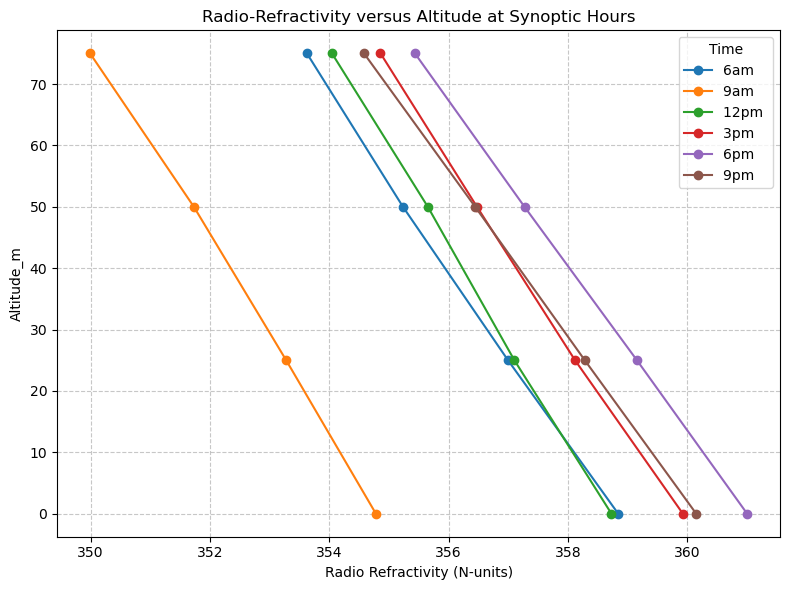

In [33]:
selected_time = ['6am', '9am', '12pm', '3pm', '6pm', '9pm']  # choose representative levels
plt.figure(figsize=(8, 6))
for alt in selected_time:
    subset = df[df['Time'] == alt].groupby('Altitude_m')['N'].mean()
    plt.plot(subset.values, subset.index, marker='o', label=f"{alt} ")

plt.xlabel("Radio Refractivity (N-units)")
plt.ylabel("Altitude_m")
plt.title("Radio-Refractivity versus Altitude at Synoptic Hours")
plt.legend(title="Time")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

#filepath = os.path.join(save_dir, "refractivity_daily_variation_by_time_selected_altitudes.png")
#plt.savefig(filepath, dpi=300)
#plt.close()

# refractivity decreases with height
what happens when refractivity decreases with height
- Enhanced Signal Range:
Radio waves curve more toward the Earth, allowing them to travel farther than under normal conditions. This can extend coverage beyond the visual horizon.
- Ducting Conditions:
In extreme cases, the refractivity gradient becomes so steep that waves get trapped between atmospheric layers and the ground, forming a tropospheric duct. Signals can then travel hundreds of kilometers with minimal loss.
- Multipath Fading:
The increased bending can cause signals to arrive at the receiver via multiple paths, leading to constructive or destructive interference—a major cause of fading in microwave links.
- Interference Risks:
Extended propagation can cause signals to reach unintended receivers or overlap with other systems, leading to co-channel interference.


## Diurnal Variation of Radio-Refractivity

C:\Users\BRING JOY\AppData\Local\Temp\ipykernel_9912\2208578401.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset = df[df['Altitude_m'] == alt].groupby('Time')['N'].mean().reindex(time_order)
C:\Users\BRING JOY\AppData\Local\Temp\ipykernel_9912\2208578401.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset = df[df['Altitude_m'] == alt].groupby('Time')['N'].mean().reindex(time_order)
C:\Users\BRING JOY\AppData\Local\Temp\ipykernel_9912\2208578401.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to 

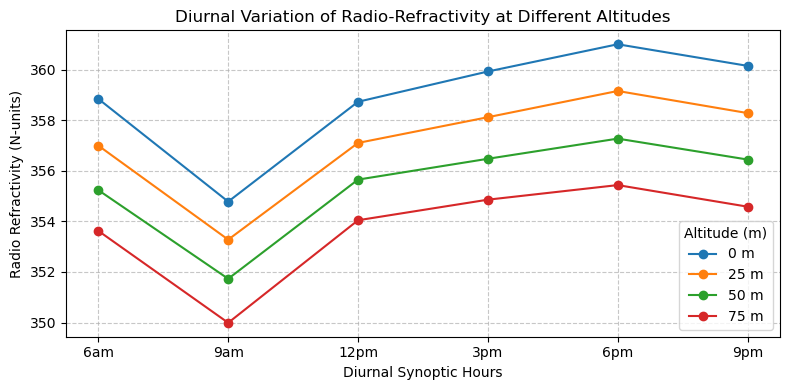

In [35]:
time_order = ["6am", "9am", "12pm", "3pm", "6pm", "9pm"]

# Convert Time column to ordered categorical type
df['Time'] = pd.Categorical(df['Time'], categories=time_order, ordered=True)

selected_altitude = [0, 25, 50, 75]  # choose representative levels
plt.figure(figsize=(8, 4))

for alt in selected_altitude:
    subset = df[df['Altitude_m'] == alt].groupby('Time')['N'].mean().reindex(time_order)
    plt.plot(time_order, subset.values, marker='o', label=f"{alt} m")

plt.xlabel("Diurnal Synoptic Hours")
plt.ylabel("Radio Refractivity (N-units)")
plt.title("Diurnal Variation of Radio-Refractivity at Different Altitudes")
plt.legend(title="Altitude (m)")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## Daily Variation of Radio Refractivity over 30 Days

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\BRING JOY\AppData\Local\Temp\ipykernel_9912\1628742198.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Day_num'] = df['Day'].str.extract('(\d+)').astype(int)


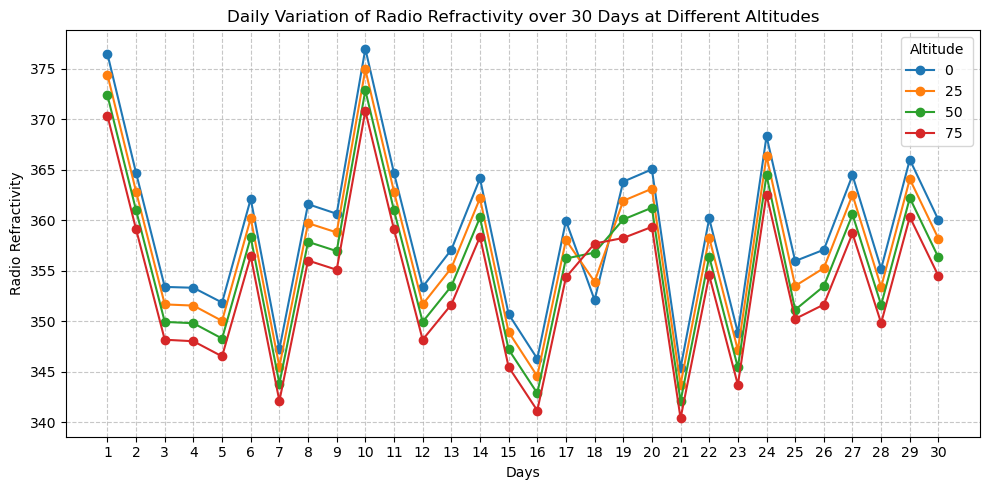

In [36]:
df['Day_num'] = df['Day'].str.extract('(\d+)').astype(int)
selected_altitude = [0, 25, 50, 75]  # choose representative levels
plt.figure(figsize=(10, 5))
for alt in selected_altitude:
    subset = df[df['Altitude_m'] == alt].groupby('Day_num')['N'].mean().sort_index()
    plt.plot(subset.index, subset.values, marker='o', label=f"{alt} ")

plt.xlabel("Days")
plt.xticks(range(1, 31))
plt.ylabel("Radio Refractivity")
plt.title("Daily Variation of Radio Refractivity over 30 Days at Different Altitudes")
plt.legend(title="Altitude")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

## Radio-Refractivity

In [231]:
pivot_df = df.pivot_table(index=["Day", "Time"], columns="Altitude_km", values="N").reset_index()
pivot_df.columns.name = None # remove multi-index name

# Rename altitude columns
pivot_df = pivot_df.rename(columns={0: "N0", 25: "N25", 50: "N50", 75: "N75"})
pivot_df

,Day,Time,N0,0.025,0.05,0.075
0,DAY 1,6am,367.8,365.8,363.9,362.0
1,DAY 1,9am,389.3,387.1,384.9,382.7
2,DAY 1,12pm,378.4,376.4,374.3,372.3
3,DAY 1,3pm,367.6,365.6,363.7,361.8
4,DAY 1,6pm,377.5,375.5,373.4,371.3
...,...,...,...,...,...,...
175,DAY 9,9am,347.9,346.2,344.5,342.9
176,DAY 9,12pm,365.4,363.5,361.6,359.7
177,DAY 9,3pm,358.7,356.8,354.9,353.0
178,DAY 9,6pm,377.5,375.5,373.4,371.3


In [233]:
# Rename altitude columns for clarity
pivot_df = pivot_df.rename(columns={0.000: "N0", 0.025: "N25", 0.050: "N50", 0.075: "N75"})
pivot_df

,Day,Time,N0,N25,N50,N75
0,DAY 1,6am,367.8,365.8,363.9,362.0
1,DAY 1,9am,389.3,387.1,384.9,382.7
2,DAY 1,12pm,378.4,376.4,374.3,372.3
3,DAY 1,3pm,367.6,365.6,363.7,361.8
4,DAY 1,6pm,377.5,375.5,373.4,371.3
...,...,...,...,...,...,...
175,DAY 9,9am,347.9,346.2,344.5,342.9
176,DAY 9,12pm,365.4,363.5,361.6,359.7
177,DAY 9,3pm,358.7,356.8,354.9,353.0
178,DAY 9,6pm,377.5,375.5,373.4,371.3


In [235]:
#Compute refractivity gradients
# Surface-referenced
pivot_df["Grad_25_0"] = (pivot_df["N25"] - pivot_df["N0"]) / (0.025 - 0.000)
pivot_df["Grad_50_0"] = (pivot_df["N50"] - pivot_df["N0"]) / (0.050 - 0.000)
pivot_df["Grad_75_0"] = (pivot_df["N75"] - pivot_df["N0"]) / (0.075 - 0.000)

# Layer-by-layer
pivot_df["Grad_50_25"] = (pivot_df["N50"] - pivot_df["N25"]) / (0.050 - 0.025)
pivot_df["Grad_75_50"] = (pivot_df["N75"] - pivot_df["N50"]) / (0.075 - 0.050)

pivot_df

,Day,Time,N0,N25,N50,N75,Grad_25_0,Grad_50_0,Grad_75_0,Grad_50_25,Grad_75_50
0,DAY 1,6am,367.8,365.8,363.9,362.0,-80.0,-78.0,-77.333333,-76.0,-76.0
1,DAY 1,9am,389.3,387.1,384.9,382.7,-88.0,-88.0,-88.000000,-88.0,-88.0
2,DAY 1,12pm,378.4,376.4,374.3,372.3,-80.0,-82.0,-81.333333,-84.0,-80.0
3,DAY 1,3pm,367.6,365.6,363.7,361.8,-80.0,-78.0,-77.333333,-76.0,-76.0
4,DAY 1,6pm,377.5,375.5,373.4,371.3,-80.0,-82.0,-82.666667,-84.0,-84.0
...,...,...,...,...,...,...,...,...,...,...,...
175,DAY 9,9am,347.9,346.2,344.5,342.9,-68.0,-68.0,-66.666667,-68.0,-64.0
176,DAY 9,12pm,365.4,363.5,361.6,359.7,-76.0,-76.0,-76.000000,-76.0,-76.0
177,DAY 9,3pm,358.7,356.8,354.9,353.0,-76.0,-76.0,-76.000000,-76.0,-76.0
178,DAY 9,6pm,377.5,375.5,373.4,371.3,-80.0,-82.0,-82.666667,-84.0,-84.0


## Surface Reference Refractivity Gradient

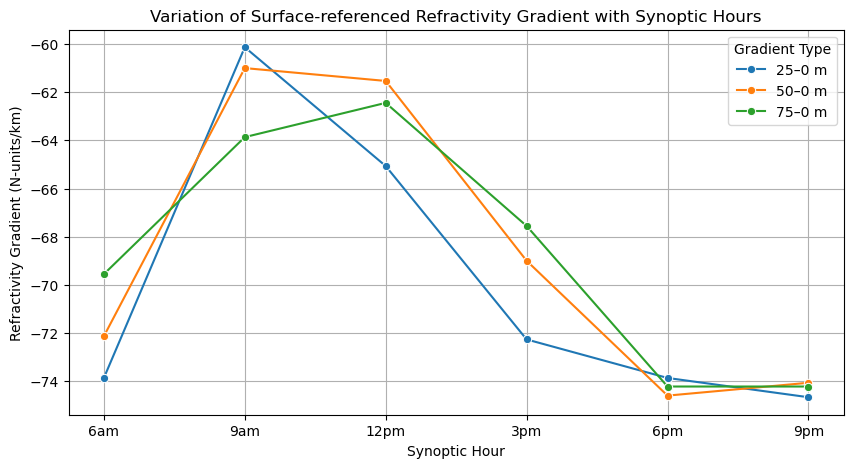

In [237]:
#Reshape for Seaborn
gradients_melted = pivot_df.melt(
    id_vars=["Day", "Time"],
    value_vars=["Grad_25_0", "Grad_50_0", "Grad_75_0"],
    var_name="Gradient_Type",
    value_name="Gradient_Value"
)

# Map gradient codes to readable labels
label_map = {
    "Grad_25_0": "25–0 m",
    "Grad_50_0": "50–0 m",
    "Grad_75_0": "75–0 m",
    "Grad_50_25": "50–25 m",
    "Grad_75_50": "75–50 m"
}
gradients_melted["Gradient_Type"] = gradients_melted["Gradient_Type"].map(label_map)

# Ensure correct ordering of Time
time_order = ["6am", "9am", "12pm", "3pm", "6pm", "9pm"]
gradients_melted["Time"] = pd.Categorical(gradients_melted["Time"], categories=time_order, ordered=True)

# ==============================
# Plain Seaborn line plot (no shading, clean legend)
# ==============================
plt.figure(figsize=(10,5))
sns.lineplot(
    data=gradients_melted,
    x="Time",
    y="Gradient_Value",
    hue="Gradient_Type",
    marker="o",
    errorbar=None
)

plt.xlabel("Synoptic Hour")
plt.ylabel("Refractivity Gradient (N-units/km)")
plt.title("Variation of Surface-referenced Refractivity Gradient with Synoptic Hours")
plt.grid(True)
plt.legend(title="Gradient Type")
plt.show()


## Layer by Layer Refractivity Gradient

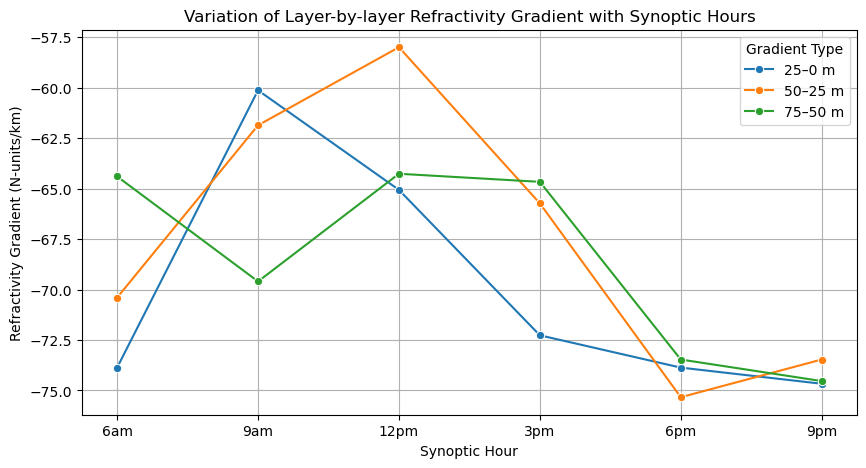

In [239]:
#Reshape for Seaborn
gradients_melted = pivot_df.melt(
    id_vars=["Day", "Time"],
    value_vars=["Grad_25_0", "Grad_50_25", "Grad_75_50"],
    var_name="Gradient_Type",
    value_name="Gradient_Value"
)

# Map gradient codes to readable labels
label_map = {
    "Grad_25_0": "25–0 m",
    "Grad_50_0": "50–0 m",
    "Grad_75_0": "75–0 m",
    "Grad_50_25": "50–25 m",
    "Grad_75_50": "75–50 m"
}
gradients_melted["Gradient_Type"] = gradients_melted["Gradient_Type"].map(label_map)

# Ensure correct ordering of Time
time_order = ["6am", "9am", "12pm", "3pm", "6pm", "9pm"]
gradients_melted["Time"] = pd.Categorical(gradients_melted["Time"], categories=time_order, ordered=True)

# ==============================
# Plain Seaborn line plot (no shading, clean legend)
# ==============================
plt.figure(figsize=(10,5))
sns.lineplot(
    data=gradients_melted,
    x="Time",
    y="Gradient_Value",
    hue="Gradient_Type",
    marker="o",
    errorbar=None
)

plt.xlabel("Synoptic Hour")
plt.ylabel("Refractivity Gradient (N-units/km)")
plt.title("Variation of Layer-by-layer Refractivity Gradient with Synoptic Hours")
plt.grid(True)
plt.legend(title="Gradient Type")
plt.show()

## Combine Refractivity Gradient at Synoptic hours

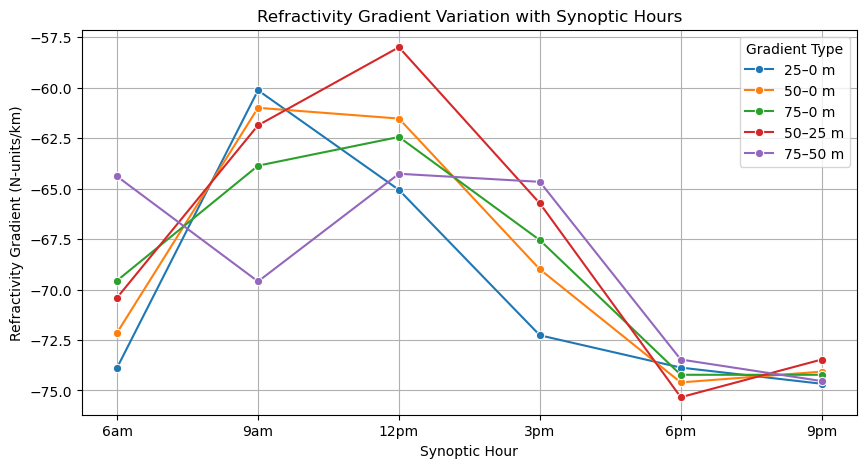

In [241]:
#Reshape for Seaborn
gradients_melted = pivot_df.melt(
    id_vars=["Day", "Time"],
    value_vars=["Grad_25_0", "Grad_50_0", "Grad_75_0", "Grad_50_25", "Grad_75_50"],
    var_name="Gradient_Type",
    value_name="Gradient_Value"
)

# Map gradient codes to readable labels
label_map = {
    "Grad_25_0": "25–0 m",
    "Grad_50_0": "50–0 m",
    "Grad_75_0": "75–0 m",
    "Grad_50_25": "50–25 m",
    "Grad_75_50": "75–50 m"
}
gradients_melted["Gradient_Type"] = gradients_melted["Gradient_Type"].map(label_map)

# Ensure correct ordering of Time
time_order = ["6am", "9am", "12pm", "3pm", "6pm", "9pm"]
gradients_melted["Time"] = pd.Categorical(gradients_melted["Time"], categories=time_order, ordered=True)

plt.figure(figsize=(10,5))
sns.lineplot(
    data=gradients_melted,
    x="Time",
    y="Gradient_Value",
    hue="Gradient_Type",
    marker="o",
    errorbar=None
)

plt.xlabel("Synoptic Hour")
plt.ylabel("Refractivity Gradient (N-units/km)")
plt.title("Refractivity Gradient Variation with Synoptic Hours")
plt.grid(True)
plt.legend(title="Gradient Type")
plt.show()

## The refractivity gradient is a key factor in determining how radio waves bend in the atmosphere. It measures how fast refractivity (N) changes with height

###  If refractive gradient (dN/dh) is negative, refractivity decreases with height (common in the troposphere).
###   0 to -40 Normal refraction       -  Slight downward bending (normal refraction)
###   -40 to -100  sub refraction      -  Less bending than normal; signals may travel shorter distances
###    -100 to -157 super refractin    - Enhanced bending; signals travel farther than expected
###    < -157 Ducting                  -  Signals trapped in a layer; can travel hundreds of kilometers
###  A large negative gradient can lead to ducting, causing radio waves to be trapped and travel long distances.

###  If refractive gradient (dN/dh) is positive, refractivity increases (rare but possible in some conditions).¶

# what happens when refractivity decreases with height
- Enhanced Signal Range:
Radio waves curve more toward the Earth, allowing them to travel farther than under normal conditions. This can extend coverage beyond the visual horizon.
- Ducting Conditions:
In extreme cases, the refractivity gradient becomes so steep that waves get trapped between atmospheric layers and the ground, forming a tropospheric duct. Signals can then travel hundreds of kilometers with minimal loss.
- Multipath Fading:
The increased bending can cause signals to arrive at the receiver via multiple paths, leading to constructive or destructive interference—a major cause of fading in microwave links.
- Interference Risks:
Extended propagation can cause signals to reach unintended receivers or overlap with other systems, leading to co-channel interference.


## K-FACTOR

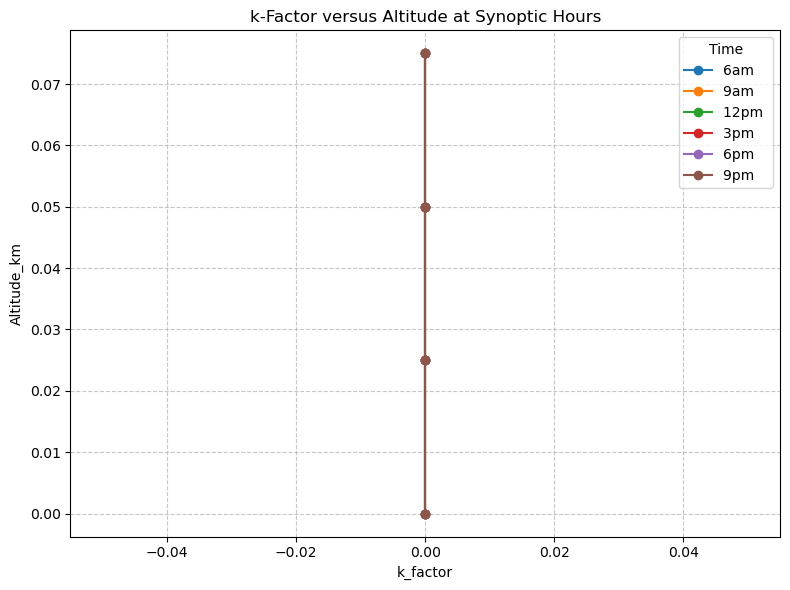

In [40]:
selected_time = ['6am', '9am', '12pm', '3pm', '6pm', '9pm']  # choose representative levels
plt.figure(figsize=(8, 6))
for alt in selected_time:
    subset = df[df['Time'] == alt].groupby('Altitude_km')['k_factor'].mean()
    plt.plot(subset.values, subset.index, marker='o', label=f"{alt} ")

plt.xlabel("k_factor")
plt.ylabel("Altitude_km")
plt.title("k-Factor versus Altitude at Synoptic Hours")
plt.legend(title="Time")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

# Interpreting the k-Factor
## The k-factor (or effective Earth radius factor) is used in radio wave propagation to model how Earth's curvature and atmospheric refraction affect the signal path. It adjusts the Earth’s radius to simulate the bending of radio waves due to atmospheric refraction.


## K < 1   subrefraction  - Waves bend less, reduced coverage
## K = 1   normal refraction - Normal refraction
## K > 1   superfraction   -  Waves bend more, extended coverage

## Geo-climatic Factor

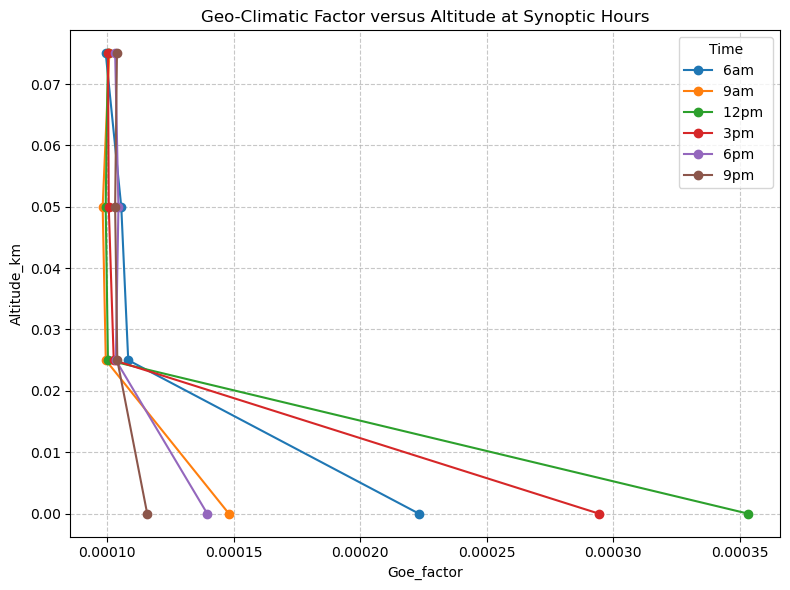

In [42]:
selected_time = ['6am', '9am', '12pm', '3pm', '6pm', '9pm']  # choose representative levels
plt.figure(figsize=(8, 6))
for alt in selected_time:
    subset = df[df['Time'] == alt].groupby('Altitude_km')['Goe_factor'].mean()
    plt.plot(subset.values, subset.index, marker='o', label=f"{alt} ")

plt.xlabel("Goe_factor")
plt.ylabel("Altitude_km")
plt.title("Geo-Climatic Factor versus Altitude at Synoptic Hours")
plt.legend(title="Time")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

# Interpreting Trends in Geoclimatic factor

## - The geoclimatic factor K is a site-dependent parameter used in radio wave propagation studies, especially for estimating  Signal Fading and Multipath Propagation

### Low multipath fading        0.00001 - 0.00005    minimal signal degradation, stable atmospheric condition

### moderate multipath fading   0.00005 - 0.00015    Noticeable fading,   typical in temperate zone or transitional seasons

### High multipath fading       > 0.00015            severe fading, common in tropical, coastal environments.


# MODEL

In [45]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [46]:
# Dependent and Independent Features
X_features = df[["Humidity_%","Temperature_C","Pressure_hPa" ]]  # Predictor
y_feature = df["N"]  # Target

In [47]:
# Train Test Split
#X_train, X_test, y_train, y_test = train_test_split(X_features_scaled, y_feature, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_features, y_feature, test_size=0.2, random_state=42)


In [48]:
# Build Model with DecisionTree Regressor

regressor_model = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [49]:
y_pred = regressor_model .predict(X_test)

In [50]:
# Check for model Accuracy
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

print("R2 Score", r2_score(y_test, y_pred))

R2 Score 0.933291370074775


In [51]:
# make a prediction
value = np.array([71.40	,25.51,961.10	]).reshape(1,-1)


In [52]:
 output = regressor_model .predict(value)
print(f"refractivity is: {output}")

refractivity is: [343.19285714]


C:\Users\BRING JOY\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [216]:
import joblib

# Save the trained model
joblib.dump(regressor_model, "regressor_model.joblib")

['regressor_model.joblib']

In [56]:
!pip install gradio


In [218]:
import joblib
import gradio as gr

# Load model
model = joblib.load("regressor_model.joblib")

# Define prediction function with classification
def predict_refractivity(humidity, temperature, pressure):
    # Prepare input in correct shape
    features = [[humidity, temperature, pressure]]
    
    # Predict refractivity
    N = model.predict(features)[0]

    # Apply refractivity range classification
    if N > 400:
        effect = "Ducting (strong bending, over-horizon)"
    elif 350 < N <= 400:
        effect = "Super-refraction (enhanced range)"
    elif 250 < N <= 350:
        effect = "Standard propagation"
    elif 200 < N <= 250:
        effect = "Sub-refraction (reduced range)"
    else:
        effect = "Anomalous or no refraction"

    return f"Refractivity: {round(N, 2)} N\nPropagation Effect: {effect}"

# Gradio interface
interface = gr.Interface(
    fn=predict_refractivity,
    inputs=[
        gr.Number(label="Humidity (%)"),
        gr.Number(label="Temperature (°C)"),
        gr.Number(label="Pressure (hPa)")
    ],
    outputs="text",
    title="Refractivity and Radio Propagation Effect Predictor",
    description="Enter environmental parameters to compute refractivity and interpret propagation behavior."
)

# Launch app
if __name__ == "__main__":
    interface.launch()

* Running on local URL:  http://127.0.0.1:7871

To create a public link, set `share=True` in `launch()`.
